In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
sns.set_style("whitegrid")
%matplotlib inline


In [3]:
n = 500

# MaKH: 'KH001' -> 'KH500'
ma_kh = [f"KH{str(i).zfill(3)}" for i in range(1, n + 1)]

# Tuoi: ngau nhien 18-70, chen 10 gia tri NaN
tuoi = np.random.randint(18, 71, size=n).astype(float)
nan_idx_tuoi = np.random.choice(n, 10, replace=False)
tuoi[nan_idx_tuoi] = np.nan

# ThuNhap: 5 trieu - 50 trieu, them 5 outliers len toi 200 trieu
thu_nhap = np.random.uniform(5_000_000, 50_000_000, size=n)
outlier_idx = np.random.choice(n, 5, replace=False)
thu_nhap[outlier_idx] = np.random.uniform(150_000_000, 200_000_000, size=5)

# GioiTinh: 'Nam' / 'Nu', chen 15 gia tri NaN
gioi_tinh = np.random.choice(['Nam', 'Nữ'], size=n).astype(object)
nan_idx_gt = np.random.choice(n, 15, replace=False)
gioi_tinh[nan_idx_gt] = np.nan

# ThanhPho
thanh_pho = np.random.choice(['Hà Nội', 'Đà Nẵng', 'TP.HCM'], size=n)

# TongChiTieu: tuong quan nhe voi ThuNhap + nhieu ngau nhien
tong_chi_tieu = thu_nhap * np.random.uniform(0.2, 0.5, size=n) + np.random.normal(0, 2_000_000, size=n)
tong_chi_tieu = np.clip(tong_chi_tieu, 0, None)

df_khachhang = pd.DataFrame({
    'MaKH': ma_kh,
    'Tuoi': tuoi,
    'ThuNhap': thu_nhap,
    'GioiTinh': gioi_tinh,
    'ThanhPho': thanh_pho,
    'TongChiTieu': tong_chi_tieu
})

df_khachhang.head(10)


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,1.986568e+07,NaN,Hà Nội,5.830094e+06
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,1.416799e+07
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,5.474525e+06
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,1.013181e+07
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,5.872465e+06
5,KH006,25.0,2.695144e+07,Nam,Đà Nẵng,7.792735e+06
6,KH007,38.0,4.328679e+07,Nữ,Đà Nẵng,1.323582e+07
7,KH008,56.0,8.954943e+06,Nam,Đà Nẵng,6.162563e+06
8,KH009,36.0,4.126392e+07,Nam,Đà Nẵng,1.451542e+07
9,KH010,40.0,7.504407e+06,Nữ,TP.HCM,5.873137e+06


## Câu 2: Xử lý giá trị khuyết (Missing Values)
Kiểm tra số lượng NaN mỗi cột, sau đó điền khuyết `Tuoi` bằng trung vị và `GioiTinh` bằng mode.

In [4]:
# Kiem tra so luong gia tri khuyet tren moi cot
print("Số lượng giá trị khuyết theo từng cột:")
print(df_khachhang.isnull().sum())

# Dien khuyet Tuoi bang Trung vi (Median)
median_tuoi = df_khachhang['Tuoi'].median()
df_khachhang['Tuoi'] = df_khachhang['Tuoi'].fillna(median_tuoi)

# Dien khuyet GioiTinh bang gia tri xuat hien nhieu nhat (Mode)
mode_gioitinh = df_khachhang['GioiTinh'].mode()[0]
df_khachhang['GioiTinh'] = df_khachhang['GioiTinh'].fillna(mode_gioitinh)

print(f"\nĐã điền Tuoi bằng median = {median_tuoi}")
print(f"Đã điền GioiTinh bằng mode = {mode_gioitinh}")
print("\nKiểm tra lại số lượng giá trị khuyết:")
print(df_khachhang.isnull().sum())


Số lượng giá trị khuyết theo từng cột:
MaKH            0
Tuoi           10
ThuNhap         0
GioiTinh       15
ThanhPho        0
TongChiTieu     0
dtype: int64

Đã điền Tuoi bằng median = 45.0
Đã điền GioiTinh bằng mode = Nữ

Kiểm tra lại số lượng giá trị khuyết:
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


## Câu 3: Mã hóa biến phân loại (One-Hot Encoding)
`ThanhPho` không có tính thứ tự nên dùng One-Hot Encoding và gộp vào DataFrame gốc.

In [5]:
thanhpho_dummies = pd.get_dummies(df_khachhang['ThanhPho'], prefix='ThanhPho')
df_khachhang = pd.concat([df_khachhang, thanhpho_dummies], axis=1)

df_khachhang.head()


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,5.830094e+06,True,False,False
1,KH002,69.0,4.701613e+07,Nam,TP.HCM,1.416799e+07,False,True,False
2,KH003,46.0,5.339046e+06,Nam,Hà Nội,5.474525e+06,True,False,False
3,KH004,32.0,1.513998e+07,Nữ,TP.HCM,1.013181e+07,False,True,False
4,KH005,60.0,2.144106e+07,Nam,Hà Nội,5.872465e+06,True,False,False


## Câu 4: Phát hiện và xử lý điểm dị biệt (Outlier Detection - IQR)
Tính Q1, Q3 cho `ThuNhap`, xác định giới hạn trên/dưới, và lọc bỏ các dòng là outlier.

In [6]:
Q1 = df_khachhang['ThuNhap'].quantile(0.25)
Q3 = df_khachhang['ThuNhap'].quantile(0.75)
IQR = Q3 - Q1

gioi_han_duoi = Q1 - 1.5 * IQR
gioi_han_tren = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:,.0f}, Q3 = {Q3:,.0f}, IQR = {IQR:,.0f}")
print(f"Giới hạn dưới = {gioi_han_duoi:,.0f}")
print(f"Giới hạn trên = {gioi_han_tren:,.0f}")

so_dong_truoc = len(df_khachhang)
df_khachhang = df_khachhang[
    (df_khachhang['ThuNhap'] >= gioi_han_duoi) & (df_khachhang['ThuNhap'] <= gioi_han_tren)
].reset_index(drop=True)
so_dong_sau = len(df_khachhang)

print(f"\nSố dòng trước khi lọc: {so_dong_truoc}")
print(f"Số dòng sau khi lọc: {so_dong_sau}")
print(f"Đã loại bỏ {so_dong_truoc - so_dong_sau} dòng outlier")


Q1 = 17,487,806, Q3 = 39,697,300, IQR = 22,209,494
Giới hạn dưới = -15,826,436
Giới hạn trên = 73,011,542

Số dòng trước khi lọc: 500
Số dòng sau khi lọc: 495
Đã loại bỏ 5 dòng outlier


## Câu 5: Chuẩn hóa dữ liệu (Feature Scaling)
Dùng `MinMaxScaler` để chuẩn hóa `TongChiTieu` về [0, 1], lưu vào cột `TongChiTieu_Scaled`.

In [7]:
scaler = MinMaxScaler()
df_khachhang['TongChiTieu_Scaled'] = scaler.fit_transform(df_khachhang[['TongChiTieu']])

df_khachhang[['TongChiTieu', 'TongChiTieu_Scaled']].head(10)


,TongChiTieu,TongChiTieu_Scaled
0,5.830094e+06,0.238278
1,1.416799e+07,0.579051
2,5.474525e+06,0.223746
3,1.013181e+07,0.414091
4,5.872465e+06,0.240010
5,7.792735e+06,0.318492
6,1.323582e+07,0.540953
7,6.162563e+06,0.251866
8,1.451542e+07,0.593251
9,5.873137e+06,0.240037


## Câu 6: Lọc dữ liệu theo điều kiện (Data Filtering)
Trích xuất khách hàng Nữ, Tuoi > 30, đang ở Hà Nội.

In [8]:
df_loc = df_khachhang[
    (df_khachhang['GioiTinh'] == 'Nữ') &
    (df_khachhang['Tuoi'] > 30) &
    (df_khachhang['ThanhPho'] == 'Hà Nội')
]

print(f"Số khách hàng thỏa điều kiện: {len(df_loc)}")
df_loc.head()


Số khách hàng thỏa điều kiện: 77


,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
0,KH001,56.0,1.986568e+07,Nữ,Hà Nội,5.830094e+06,True,False,False,0.238278
15,KH017,41.0,3.091993e+07,Nữ,Hà Nội,1.428630e+07,True,False,False,0.583887
17,KH019,39.0,5.238500e+06,Nữ,Hà Nội,2.906416e+06,True,False,False,0.118786
18,KH020,70.0,4.887802e+07,Nữ,Hà Nội,1.968249e+07,True,False,False,0.804431
20,KH022,41.0,3.753032e+07,Nữ,Hà Nội,1.312164e+07,True,False,False,0.536287


## Câu 7: Gom nhóm và Thống kê (Aggregation)
Tính Mean và Sum của `TongChiTieu` theo từng `ThanhPho`.

In [9]:
thong_ke_thanhpho = df_khachhang.groupby('ThanhPho')['TongChiTieu'].agg(['mean', 'sum'])
thong_ke_thanhpho.columns = ['TrungBinh_ChiTieu', 'Tong_ChiTieu']

thong_ke_thanhpho


,TrungBinh_ChiTieu,Tong_ChiTieu
ThanhPho,,
Hà Nội,9.777202e+06,1.779451e+09
TP.HCM,1.057790e+07,1.734776e+09
Đà Nẵng,1.002583e+07,1.493848e+09


## Câu 8: Kỹ nghệ đặc trưng (Feature Engineering)
Tạo cột `NhomTuoi` từ `Tuoi` bằng `pd.cut()`.

In [10]:
bins = [17, 30, 45, 60, 200]
labels = ['18-30', '31-45', '46-60', 'Trên 60']

df_khachhang['NhomTuoi'] = pd.cut(df_khachhang['Tuoi'], bins=bins, labels=labels)

df_khachhang[['Tuoi', 'NhomTuoi']].head(10)


,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60
5,25.0,18-30
6,38.0,31-45
7,56.0,46-60
8,36.0,31-45
9,40.0,31-45


In [11]:
# Kiem tra phan bo cac nhom tuoi
df_khachhang['NhomTuoi'].value_counts().sort_index()


,count
NhomTuoi,
18-30,107
31-45,151
46-60,139
Trên 60,98


## Câu 9: Ma trận tương quan (Correlation Matrix)
Tính tương quan Pearson giữa `Tuoi`, `ThuNhap`, `TongChiTieu` và vẽ heatmap.

Ma trận tương quan Pearson:
                 Tuoi   ThuNhap  TongChiTieu
Tuoi         1.000000 -0.037474    -0.028577
ThuNhap     -0.037474  1.000000     0.815948
TongChiTieu -0.028577  0.815948     1.000000


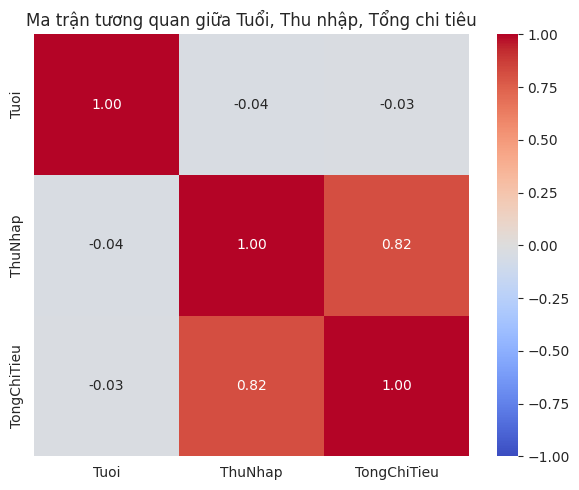

In [12]:
corr_matrix = df_khachhang[['Tuoi', 'ThuNhap', 'TongChiTieu']].corr(method='pearson')
print("Ma trận tương quan Pearson:")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa Tuổi, Thu nhập, Tổng chi tiêu')
plt.tight_layout()
plt.show()


## Câu 10: Trực quan hóa dữ liệu (Scatter Plot)
Mối quan hệ giữa `ThuNhap` (X) và `TongChiTieu` (Y), tô màu theo `GioiTinh`.

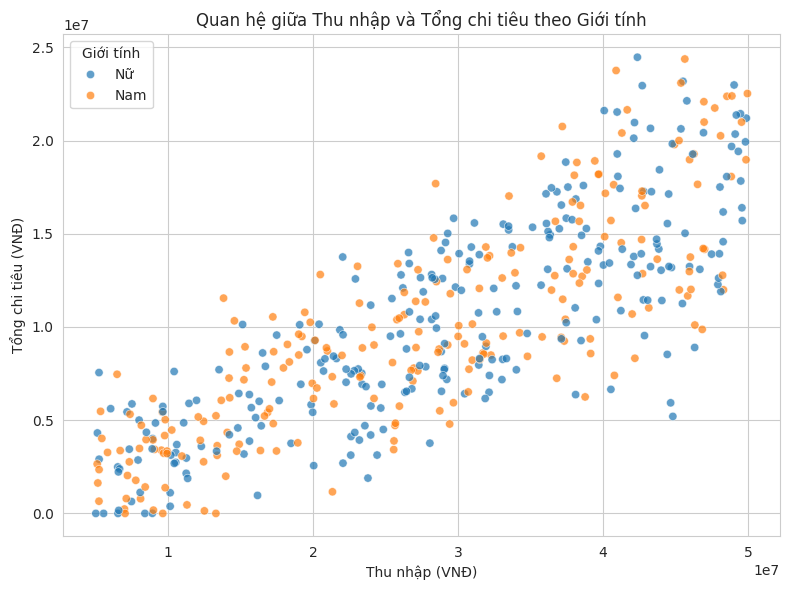

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_khachhang, x='ThuNhap', y='TongChiTieu', hue='GioiTinh', alpha=0.7)
plt.title('Quan hệ giữa Thu nhập và Tổng chi tiêu theo Giới tính')
plt.xlabel('Thu nhập (VNĐ)')
plt.ylabel('Tổng chi tiêu (VNĐ)')
plt.legend(title='Giới tính')
plt.tight_layout()
plt.show()


---
# PHẦN 2: Ứng dụng Học sâu - Mạng Nơ-ron Tích chập (CNN)
## Câu 11: Xây dựng và Huấn luyện mô hình CNN với Fashion MNIST

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


### Bước 1: Tải và tiền xử lý dữ liệu
Tải Fashion MNIST, chuẩn hóa pixel về [0, 1], reshape thêm kênh màu.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước tập train: (60000, 28, 28)
Kích thước tập test: (10000, 28, 28)
Sau khi reshape - train: (60000, 28, 28, 1)
Sau khi reshape - test: (10000, 28, 28, 1)


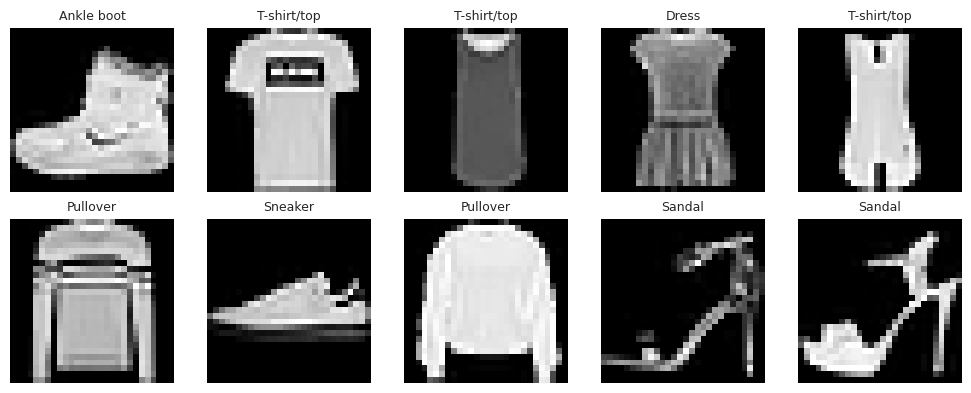

In [15]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Kích thước tập train:", x_train.shape)
print("Kích thước tập test:", x_test.shape)

# Chuan hoa gia tri pixel ve [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape them kenh mau (28, 28, 1) vi anh xam
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Sau khi reshape - train:", x_train.shape)
print("Sau khi reshape - test:", x_test.shape)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Xem thu vai anh mau
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


### Bước 2: Xây dựng kiến trúc CNN
Conv2D(32, 3x3, ReLU) -> MaxPooling2D -> Flatten -> Dense(64, ReLU) -> Dense(10, Softmax).

In [16]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Bước 3: Biên dịch và Huấn luyện mô hình

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.8382 - loss: 0.4589 - val_accuracy: 0.8812 - val_loss: 0.3414
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8907 - loss: 0.3100 - val_accuracy: 0.8953 - val_loss: 0.3013
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.9048 - loss: 0.2650 - val_accuracy: 0.8988 - val_loss: 0.2843
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9158 - loss: 0.2358 - val_accuracy: 0.9050 - val_loss: 0.2556
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9228 - loss: 0.2122 - val_accuracy: 0.9102 - val_loss: 0.2500


### Bước 4: Đánh giá mô hình trên tập kiểm thử (test data)

In [18]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Độ chính xác (Accuracy) trên tập test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test loss: {test_loss:.4f}")


Độ chính xác (Accuracy) trên tập test: 0.9035 (90.35%)
Test loss: 0.2687


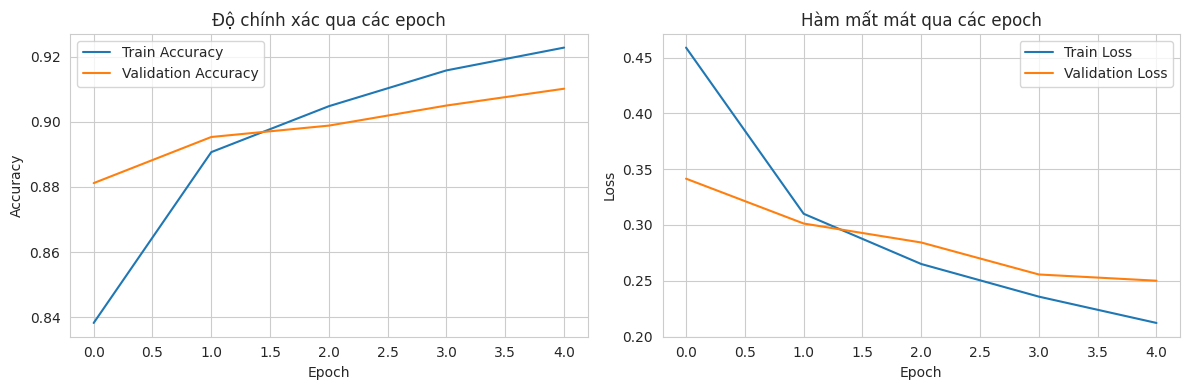

In [19]:
# Truc quan hoa qua trinh huan luyen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Độ chính xác qua các epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Hàm mất mát qua các epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()
